<a href="https://colab.research.google.com/github/DhawaDong/BioMedical-Data-Lab/blob/main/CNN_TeaLeafDiseaseDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import time
import csv
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import random
from PIL import Image
import torch.nn as nn
import albumentations
import seaborn as sns
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader #TensorDataset
from torchvision import transforms
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

In [2]:
''' SEED Everything '''
def seed_everything(SEED=42):
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
SEED=42
seed_everything(SEED=SEED)
''' SEED Everything '''
# set computation device
device = ('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}")

Computation device: cuda:0


Now Create dataset with csv dataset for using different images and its corresponding class

In [ ]:
#function to create csv file of image path and corresponding image class
def create_image_csv(root_folder, csv_filename):
    with open(csv_filename, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow(['Class', 'Image_Path'])  # Header

        for class_name in os.listdir(root_folder):
            class_folder = os.path.join(root_folder, class_name)

            if os.path.isdir(class_folder):
                for image_name in os.listdir(class_folder):
                    if image_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                        image_path = os.path.join(class_folder, image_name)
                        csv_writer.writerow([class_name, image_path])

Save CSV file created to my drive

In [ ]:
root_folder_path = '/content/drive/MyDrive/7#MachineLearning#Projects/tea sickness dataset'
csv_file = 'TeaLeaf_ImageDataSet.csv'

# Call the function to create the CSV file
create_image_csv(root_folder_path, csv_file)

# Read the CSV file into a DataFrame
#df = pd.read_csv(csv_file)

#save the csv file to google drive ..
#df.to_csv('/content/drive/MyDrive/7#MachineLearning#Projects/TeaLeaf_ImageDataSet.csv') # + csv_file_path)

In [3]:
LeafDataSet = pd.read_csv('/content/drive/MyDrive/7#MachineLearning#Projects/TeaLeaf_ImageDataSet.csv');
#Imageinput ant classes....
LeafDataSet["Class"].replace({"white spot": 0, "Anthracnose": 1,
                              "healthy": 2,   "brown blight": 3,
                              "bird eye spot": 4, "algal leaf": 5,
                              "red leaf spot": 6, "gray light": 7}, inplace = True)

/tmp/ipykernel_1552/120507938.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  LeafDataSet["Class"].replace({"white spot": 0, "Anthracnose": 1,
/tmp/ipykernel_1552/120507938.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  LeafDataSet["Class"].replace({"white spot": 0, "Anthracnose": 1,


In [4]:
#randomaize the dataset
Rand_LeafDataSet = LeafDataSet.sample(frac=1, random_state=46)

In [5]:
X = Rand_LeafDataSet.Image_Path.values   #Class', 'Image_Path'
y = Rand_LeafDataSet.Class.values

print(X.size)

885


In [6]:
(xtrain, xtest, ytrain, ytest) = train_test_split(X, y, test_size=0.20, random_state=42)

In [7]:
print(xtrain.size)

708


In [8]:
#frequency of class in TrainSet
(unique, counts) = np.unique(ytrain, return_counts=True)
Trainfrequencies = np.asarray((unique, counts)).T
#Trainfrequencies

In [9]:
# image dataset module
class DDSMimageDataset(Dataset):
    def __init__(self, path, labels, tfms=None):
        self.X = path
        self.y = labels
        # apply augmentations
        if tfms == 0:  # if validating
            self.aug = albumentations.Compose([
                albumentations.Resize(224, 224, always_apply=True),
                albumentations.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], always_apply=True)
            ])
        else:  # if training
            self.aug = albumentations.Compose([
                albumentations.Resize(224, 224, always_apply=True),
                albumentations.HorizontalFlip(p=0.5),  # Adjust probability as needed
                albumentations.ShiftScaleRotate(shift_limit=0.3, scale_limit=0.3, rotate_limit=30, p=0.5),  # Adjust parameters as needed
                albumentations.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], always_apply=True)
            ])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        image = Image.open(self.X[i])
        image = self.aug(image=np.array(image))['image']
        label = self.y[i]
        # Transpose the image to have channels first (C, H, W)
        image = np.transpose(image, (2, 0, 1)).astype(np.float32)
        return torch.tensor(image, dtype=torch.float), torch.tensor(label, dtype=torch.long)


In [10]:
BatchSize = 64
#trinaing data_set
train_data = DDSMimageDataset(xtrain, ytrain, tfms=1)
train_loader = DataLoader(train_data, batch_size=BatchSize, shuffle=True)

#testing data_set
test_data = DDSMimageDataset(xtest, ytest, tfms=0)
test_loader = DataLoader(test_data, batch_size=BatchSize, shuffle=False)

/tmp/ipykernel_1552/4187323406.py:14: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  albumentations.Resize(224, 224, always_apply=True),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_1552/4187323406.py:17: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  albumentations.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], always_apply=True)
/tmp/ipykernel_1552/4187323406.py:9: UserWarning: Argument(s) 'always_apply' are not valid for transform Resize
  albumentations.Resize(224, 224, always_apply=True),
/tmp/ipykernel_1552/4187323406.py:10: UserWarning: Argument(s) 'always_apply' are not valid for transform Normalize
  albumentations.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], always_apply=True)


In [11]:
# Define CNN architecture
class TeaLeafClassifier(nn.Module):
    def __init__(self, num_classes=8):  # Specify the number of classes
        super(TeaLeafClassifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        #self.fc1 = nn.Linear(32 * 16 * 16, 256)
        self.fc1 = nn.Linear(32 * 56 * 56, 256)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)  # Adjust the number of output neurons
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.conv1(x)
        #print("After conv1:", x.size())
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        #print("After conv2:", x.size())
        x = self.relu2(x)
        x = self.pool2(x)

        #x = x.view(-1, 32 * 16 * 16)
        x = x.view(-1, 32 * 56 * 56)  # Reshape for fully connected layer
        #print("After flattening:", x.size())

        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        #x = self.softmax(x)

        return x

In [12]:
# Instantiate the model
model = TeaLeafClassifier(num_classes=8).to(device)

In [13]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
#optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [14]:
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images.to(device))
        #loss = criterion(outputs, torch.argmax(labels.to(device), dim=1))
        loss = criterion(outputs, labels.to(device))
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/10], Loss: 1.2115
Epoch [2/10], Loss: 1.2907
Epoch [3/10], Loss: 1.1845
Epoch [4/10], Loss: 0.6031
Epoch [5/10], Loss: 0.8825
Epoch [6/10], Loss: 0.4455
Epoch [7/10], Loss: 1.0214
Epoch [8/10], Loss: 1.3755
Epoch [9/10], Loss: 0.4041
Epoch [10/10], Loss: 0.8967


Test Accuracy: 0.6949


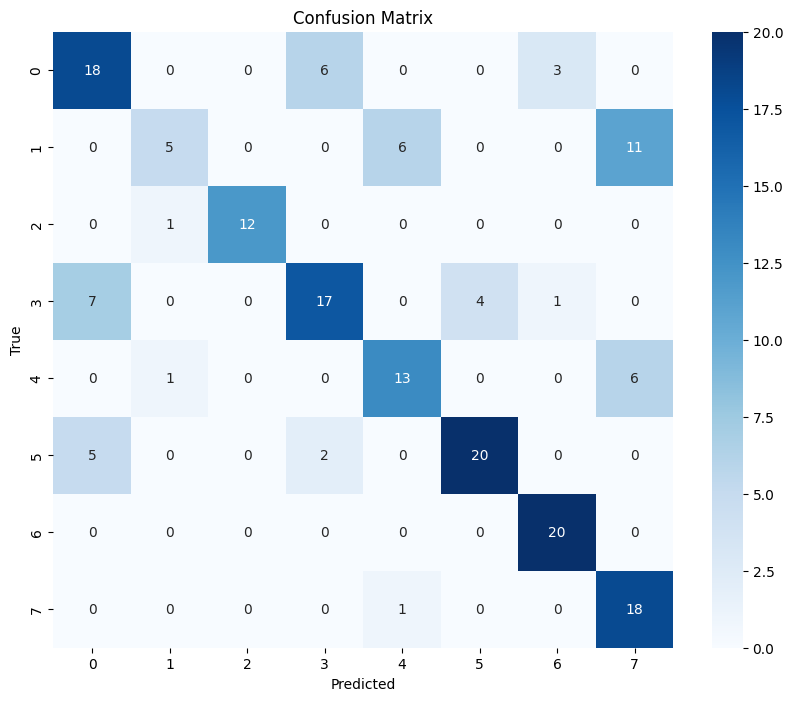

In [15]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Collect results for confusion matrix
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate Accuracy
correct = (np.array(all_preds) == np.array(all_labels)).sum()
accuracy = correct / len(all_labels)
print(f'Test Accuracy: {accuracy:.4f}')

# Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [16]:
# and finding their average weighted by support (the number of true instances for each label).
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

# Detailed breakdown per class
#print("\nDetailed Classification Report:")
#print(classification_report(all_labels, all_preds))

Precision: 0.7151
Recall:    0.6949
F1 Score:  0.6802

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.67      0.63        27
           1       0.71      0.23      0.34        22
           2       1.00      0.92      0.96        13
           3       0.68      0.59      0.63        29
           4       0.65      0.65      0.65        20
           5       0.83      0.74      0.78        27
           6       0.83      1.00      0.91        20
           7       0.51      0.95      0.67        19

    accuracy                           0.69       177
   macro avg       0.73      0.72      0.70       177
weighted avg       0.72      0.69      0.68       177

